# Anomaly Detection in Machine Learning

## Definition
Anomaly Detection is the process of identifying rare, unusual, or suspicious data points that significantly deviate from normal patterns in the dataset.

---

## Why It Is Used
Anomaly detection is commonly used for:
- Fraud detection
- Network intrusion detection
- Machine failure detection
- Predictive maintenance
- Healthcare monitoring
- Suspicious user behavior detection

---

## Main Idea
The model learns the pattern of **normal data** and flags data points that are very different from normal behavior as **anomalies**.

---

## Types of Anomalies
1. **Point Anomaly**  
   A single data point is abnormal.

2. **Contextual Anomaly**  
   A data point is abnormal only in a specific context.

3. **Collective Anomaly**  
   A group of data points together is abnormal.

---

## Types of Approaches
### 1. Supervised Anomaly Detection
Used when labeled data is available:
- Normal
- Anomaly

### 2. Unsupervised Anomaly Detection
Most common approach because anomaly labels are usually unavailable.

### 3. Semi-Supervised Anomaly Detection
Train the model only on normal data, and detect deviations as anomalies.

---

## Important Algorithms
- **Isolation Forest** ⭐
- **Local Outlier Factor (LOF)**
- **One-Class SVM**
- **DBSCAN**
- **K-Means (distance-based anomaly detection)**
- **Autoencoders**

---

## Why Isolation Forest Is Popular
Isolation Forest is widely used because:
- Anomalies are rare and different
- They are isolated in fewer random splits
- It is fast and scalable
- Works well on large datasets

---

## Evaluation Metrics
Accuracy is not reliable because anomaly detection datasets are usually imbalanced.

Preferred metrics:
- **Precision**
- **Recall**
- **F1-score**
- **ROC-AUC**
- **PR-AUC** ⭐

---

## Challenges
- Very few anomaly examples
- Highly imbalanced data
- Hard to define normal behavior
- Threshold selection is difficult
- Noise can be confused with anomalies
- Concept drift in real-world systems

---

## Real-World Use Cases
- Credit card fraud detection
- Cybersecurity intrusion detection
- Manufacturing defect detection
- Predictive maintenance using sensor data
- Abnormal patient health monitoring
- E-commerce bot/fake activity detection

---

## Best Interview Summary
Anomaly Detection is a machine learning technique used to identify rare or unusual observations that deviate from normal behavior. It is widely used in fraud detection, intrusion detection, and predictive maintenance. Since anomaly labels are often unavailable, unsupervised methods like Isolation Forest, LOF, DBSCAN, and One-Class SVM are commonly used. Because the data is highly imbalanced, evaluation is typically done using Precision, Recall, F1-score, and PR-AUC instead of accuracy.

---

## Quick Revision
- Detects unusual or rare data points
- Mostly unsupervised
- Best algorithm: **Isolation Forest**
- Important metrics: **Precision, Recall, F1-score, PR-AUC**
- Common use cases: **Fraud, Security, Machine faults**

# Isolation Forest in Machine Learning

## Definition
Isolation Forest is an **unsupervised anomaly detection algorithm** used to identify rare and unusual data points (outliers) by isolating them from the rest of the data.

---

## Main Idea
The core idea of Isolation Forest is:

- Anomalies are **few**
- Anomalies are **different**
- Because of this, anomalies are easier to isolate using random splits

So:
- **Normal points** need **more splits** to isolate
- **Anomalies** need **fewer splits** to isolate

---

## How It Works
Isolation Forest builds multiple random decision trees.

### Steps:
1. Randomly select a feature
2. Randomly select a split value between min and max of that feature
3. Repeat splitting until the data point is isolated
4. Measure the **path length** (number of splits)

### Key Logic:
- **Short path length** → likely anomaly
- **Long path length** → likely normal

---

## Why It Is Called "Isolation" Forest
Unlike traditional models that try to profile normal points, Isolation Forest directly tries to **isolate observations**.

Since anomalies are rare and different, they get isolated much faster.

---

## Why It Is Popular
Isolation Forest is widely used because:

- Works well for anomaly detection
- Fast and efficient
- Scales to large datasets
- Handles high-dimensional data
- Does not require labeled data
- Usually performs better than distance-based methods on large data

---

## Important Interview Point
**Isolation Forest is popular because anomalies are easier to isolate than normal points, so they have shorter average path lengths in random trees.**

---

## Mathematical Intuition
An anomaly score is calculated based on the **average path length** across all trees.

- **Smaller average path length** → higher anomaly score
- **Larger average path length** → lower anomaly score

---

## Key Parameters in Scikit-Learn
- **n_estimators** → number of trees
- **max_samples** → number of samples used to build each tree
- **contamination** → expected proportion of anomalies in the dataset
- **random_state** → ensures reproducibility

---

## Output in Scikit-Learn
Isolation Forest returns:

- **1** → Normal point
- **-1** → Anomaly (outlier)

---

## Advantages
- Unsupervised learning
- Fast on large datasets
- Good for high-dimensional data
- No need for distance calculations
- Works well when anomalies are rare
- Easy to implement

---

## Limitations
- May not perform well if anomalies are not clearly separable
- Sensitive to contamination parameter
- Interpretation can be less intuitive than simple statistical methods
- Can struggle if normal data itself is highly irregular

---

## Real-World Use Cases
- Credit card fraud detection
- Network intrusion detection
- Manufacturing fault detection
- Sensor anomaly detection
- Healthcare abnormality detection
- E-commerce suspicious behavior detection

---

## Evaluation Metrics
Since anomaly detection datasets are usually imbalanced, avoid relying only on accuracy.

Preferred metrics:
- **Precision**
- **Recall**
- **F1-score**
- **PR-AUC**
- **ROC-AUC**

---

## Best Interview Answer
Isolation Forest is an unsupervised anomaly detection algorithm that works by randomly partitioning the data and isolating observations. Since anomalies are rare and different from normal points, they get isolated in fewer splits and therefore have shorter path lengths in the trees. This makes Isolation Forest fast, scalable, and very effective for large anomaly detection problems.

---

## Quick Revision
- Unsupervised anomaly detection algorithm
- Uses random splits to isolate points
- Fewer splits = anomaly
- More splits = normal
- Short path length = anomaly
- Best for large datasets
- Output: **-1 = anomaly, 1 = normal**

In [2]:
import pandas as pd
df=pd.read_csv('data/healthcare.csv')
df.head()

,patient_id,age,heart_rate,blood_pressure_sys,blood_pressure_dia,glucose_level,bmi,cholesterol
0,1,25,72,120,80,90,22.5,180
1,2,34,78,125,82,95,24.1,190
2,3,45,85,130,85,110,27.8,210
3,4,52,88,135,88,115,29.3,220
4,5,29,76,118,78,88,23.0,175


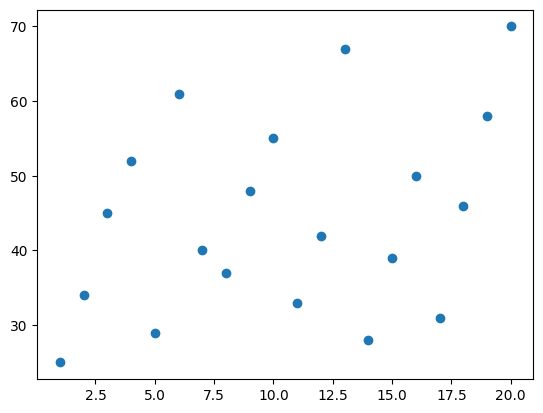

In [3]:
import matplotlib.pyplot as plt
plt.scatter(df.iloc[:,0], df.iloc[:,1])

In [9]:
from sklearn.ensemble import IsolationForest
clf = IsolationForest(contamination=0.2)
clf.fit(df)
predictions = clf.predict(df)
predictions

array([-1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1, -1,  1,  1,  1,
        1,  1, -1])

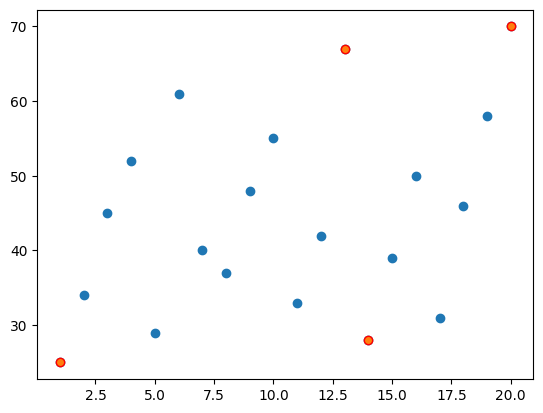

In [10]:
import numpy as np
index = np.where(predictions < 0)
index
x=df.values
index = np.where(predictions < 0)
plt.scatter(df.iloc[:,0], df.iloc[:,1])
plt.scatter(x[index,0], x[index,1], edgecolors="r")